In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import torch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder

from src.io import load_data
from src.feature import annotate_labels, our_feature
from src.utils import (
    diff_cycles,
    savgol_smooth,
    nanmax,
    nanmin,
    nanmean,
    nanskew,
    nanvar,
    nankurtosis,
)
from src.learning import random_fit_and_eval, set_seed

In [8]:
# data_folder = Path.cwd().parent / 'data/raw'
data_folder = './data/raw'

data = load_data(data_folder)

fixed_labels = annotate_labels(data, label_mode='fixed')
relative_labels = annotate_labels(data, label_mode='relative')

Loading cells:   0%|          | 0/151 [00:00<?, ?it/s]

Loading cells: 100%|██████████| 151/151 [07:52<00:00,  3.13s/it]


In [9]:
data.keys()

dict_keys(['0131-2_6', '0131-2_7', '0131-2_8', '0131-3_2', '0131-3_3', '0131-3_4', '0131-3_5', '0131-3_6', '0201-1_1', '0201-1_2', '0201-1_3', '0201-1_4', '0201-1_5', '0201-1_6', '0201-1_7', '0201-1_8', '0201-2_1', '0201-2_2', '0201-2_3', '0201-2_4', '0201-2_6', '0201-2_7', '0201-2_8', '0201-3_1', '0201-3_2', '0201-3_3', '0201-3_4', '0201-3_5', '0201-3_6', '0202-1_1', '0202-1_2', '0202-1_3', '0202-1_4', '0202-1_5', '0202-1_6', '0202-1_7', '0202-1_8', '0202-2_1', '0202-2_2', '0202-2_3', '0202-2_4', '0202-2_6', '0202-2_7', '0202-2_8', '0202-3_1', '0202-3_2', '0202-3_3', '0202-3_4', '0202-3_5', '0202-3_6', '0829-4_1', '0829-4_2', '0829-4_3', '0829-4_4', '0829-4_5', '0829-4_6', '0829-4_7', '0829-4_8', '0829-5_1', '0829-5_2', '0829-5_3', '0829-5_4', '0829-5_5', '0829-5_6', '0829-5_7', '0829-5_8', '0829-6_1', '0829-6_2', '0829-6_3', '0829-6_4', '0909-1_1', '0909-1_2', '0909-1_3', '0909-1_4', '0909-1_5', '0909-1_6', '0909-1_7', '0909-2_1', '0909-2_2', '0909-2_3', '0909-2_4', '0909-2_6', '0909

In [10]:
xps_df = pd.read_csv('./data/xps_data.csv', index_col=0)
y_fixed = [fixed_labels[x] for x in xps_df.date_tag]
y_rel = [relative_labels[x] for x in xps_df.date_tag]
xps_df = xps_df.assign(**{
    'CO': xps_df['C1s'] + xps_df['O1s'],
    'PF': xps_df['P2p'] + xps_df['F1s'],
    'CO/(CO+PF)': (xps_df['C1s'] + xps_df['O1s']) / (
        xps_df['C1s'] + xps_df['O1s'] + xps_df['P2p'] + xps_df['F1s']
    ),
    'life_fixed': y_fixed,
    'life_relative': y_rel,
    'temperature': xps_df.temp1
})
xps_target_columns = [
    'Li1s', 'C1s', 'O1s', 'F1s',
    'P2p', 'Ni3p1', 'Co3p1', 'Mn3p',
    'CO', 'PF', 'CO/(CO+PF)'
]
xps_df = xps_df[
    ['date_tag', 'type', 'life_fixed', 'life_relative', 'temperature'] + xps_target_columns
]

In [11]:
aggregated_data = []
for tag, g in xps_df.groupby(['date_tag', 'type']):
    g_imputed = SimpleImputer(strategy='median').fit_transform(g[xps_target_columns])
    numbers = KMeans(1).fit(g_imputed).cluster_centers_[0]
    aggregated_data.append(g.values[0, :5].tolist() + numbers.tolist())
xps_df_agg = pd.DataFrame(aggregated_data, columns=xps_df.columns)

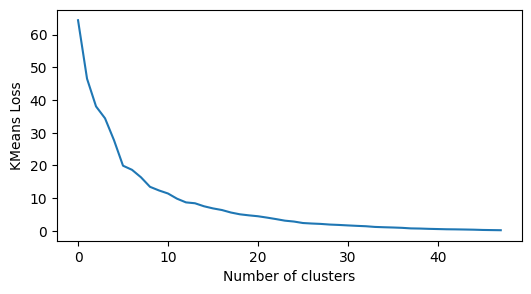

In [12]:
to_study = xps_df_agg[xps_df_agg.type == 'E']
cols_to_study = xps_target_columns[:-3]

losses = []
silhouette_scores = []
for K in range(2, 50):
    kmeans = KMeans(K, random_state=42).fit(to_study[cols_to_study])
    losses.append(kmeans.inertia_ / len(to_study))

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
ax.plot(losses)
ax.set_ylabel('KMeans Loss')
ax.set_xlabel('Number of clusters')
plt.show()


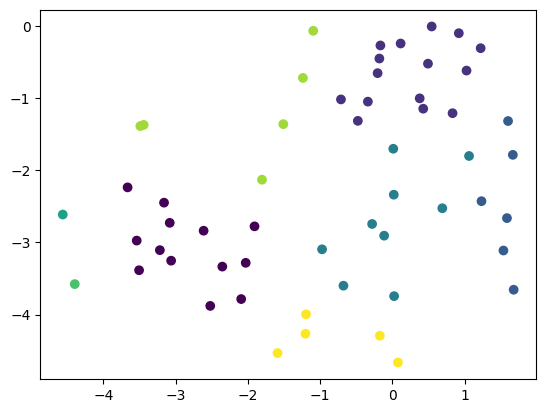

,Li1s,C1s,O1s,F1s,P2p,Ni3p1,Co3p1,Mn3p
0,21.366923,32.980000,24.451846,14.800154,4.492154,1.037846,0.785077,0.037538
1,27.584800,22.354400,31.771067,12.771600,3.142067,0.935067,1.420800,0.057067
2,32.561000,18.134333,25.597333,17.761333,2.859833,0.703000,2.353667,0.042667
3,27.033778,23.652222,25.940889,17.484222,3.657444,0.878444,1.561333,0.053111
4,3.620000,42.030000,33.076000,17.632000,1.888000,0.718000,0.426000,0.962000
5,18.000000,51.434000,17.158000,10.156000,1.656000,0.636000,0.862000,0.098000
6,24.794333,30.549000,30.682667,9.312333,2.505833,0.887000,0.646333,0.012000
7,25.456000,25.879200,19.643200,22.399600,4.365200,0.976400,1.244800,0.035600


In [13]:
kmeans = KMeans(8, random_state=42).fit(to_study[cols_to_study])

centers, clusters = kmeans.cluster_centers_, kmeans.labels_

plt.scatter(
    *TSNE().fit_transform(to_study[cols_to_study]).T, c=clusters
)
plt.show()

pd.DataFrame(centers, columns=cols_to_study)

In [ ]:
group_dict = {}
for center, (gid, g) in zip(centers, to_study.groupby(clusters)):
    # print(f'Group {gid}:')
    group_dict[gid] = g['date_tag'].values.tolist()
    
    

In [26]:
import json
# Dump the dictionary to a JSON file
with open('./data/cluster_group_detail.json', 'w') as json_file:
    json.dump(group_dict, json_file, indent=4)

In [14]:
from IPython.display import display

for center, (gid, g) in zip(centers, to_study.groupby(clusters)):
    print(f'Group {gid}:')
    display(pd.DataFrame({
        k: [v] for k, v in zip(cols_to_study, center)
    }, index=['Cluster center']))
    display(g)
    print()

Group 0:


,Li1s,C1s,O1s,F1s,P2p,Ni3p1,Co3p1,Mn3p
Cluster center,21.366923,32.98,24.451846,14.800154,4.492154,1.037846,0.785077,0.037538


,date_tag,type,life_fixed,life_relative,temperature,Li1s,C1s,O1s,F1s,P2p,Ni3p1,Co3p1,Mn3p,CO,PF,CO/(CO+PF)
38,0202-3_4,E,110,159,25,20.766,33.630,27.310,12.786,3.676,1.086,0.720,0.026,60.940,16.462,0.787074
40,0202-3_5,E,68,106,25,18.774,33.524,25.534,15.128,4.958,1.016,1.034,0.036,59.058,20.086,0.746375
46,0909-1_3,E,608,509,70,20.656,36.706,21.818,13.618,5.070,0.866,0.736,0.090,58.524,18.688,0.758241
50,0909-1_7,E,719,501,70,22.730,30.240,21.812,17.832,5.454,0.926,0.684,0.108,52.052,23.286,0.690711
52,0909-2_2,E,420,353,70,21.806,32.080,20.896,17.800,4.944,1.432,1.000,0.038,52.976,22.744,0.698596
54,0909-2_6,E,659,486,70,23.240,31.106,23.276,15.752,5.088,0.830,0.656,0.054,54.382,20.840,0.722738
78,1013-5_2,E,127,169,30,21.200,33.828,25.690,13.634,3.888,0.998,0.730,0.036,59.518,17.522,0.772685
80,1013-5_3,E,153,213,30,19.842,33.572,24.728,15.534,4.610,1.112,0.602,0.006,58.300,20.144,0.742968
82,1013-5_4,E,128,182,30,18.864,35.810,24.670,13.884,4.822,1.038,0.874,0.032,60.480,18.706,0.763888
100,1013-6_5,E,134,157,30,20.538,37.384,27.028,9.944,2.852,1.408,0.848,0.000,64.412,12.796,0.834954



Group 1:


,Li1s,C1s,O1s,F1s,P2p,Ni3p1,Co3p1,Mn3p
Cluster center,27.5848,22.3544,31.771067,12.7716,3.142067,0.935067,1.4208,0.057067


...

,Li1s,C1s,O1s,F1s,P2p,Ni3p1,Co3p1,Mn3p
Cluster center,24.794333,30.549,30.682667,9.312333,2.505833,0.887,0.646333,0.012


,date_tag,type,life_fixed,life_relative,temperature,Li1s,C1s,O1s,F1s,P2p,Ni3p1,Co3p1,Mn3p,CO,PF,CO/(CO+PF)
14,0202-1_7,E,9,47,25,25.876,28.410,29.002,11.718,3.572,0.634,0.786,0.000,57.412,15.290,0.790284
26,0202-2_6,E,32,60,25,24.776,29.060,27.328,13.894,3.204,1.038,0.700,0.002,56.388,17.098,0.766761
86,1013-5_6,E,148,203,30,26.626,27.026,34.146,8.412,2.178,1.004,0.604,0.002,61.172,10.590,0.852432
88,1013-5_7,E,133,201,30,26.040,27.564,31.456,10.922,2.400,0.884,0.576,0.052,59.020,13.189,0.818959
96,1013-6_3,E,194,238,30,23.748,35.920,31.082,5.920,1.872,0.892,0.572,0.000,67.002,7.792,0.895892
98,1013-6_4,E,246,246,30,21.700,35.314,31.082,5.008,1.809,0.870,0.640,0.016,66.396,6.988,0.907652



Group 7:


,Li1s,C1s,O1s,F1s,P2p,Ni3p1,Co3p1,Mn3p
Cluster center,25.456,25.8792,19.6432,22.3996,4.3652,0.9764,1.2448,0.0356


,date_tag,type,life_fixed,life_relative,temperature,Li1s,C1s,O1s,F1s,P2p,Ni3p1,Co3p1,Mn3p,CO,PF,CO/(CO+PF)
24,0202-2_4,E,4,12,25,19.912,26.866,24.132,23.768,3.454,1.142,0.676,0.048,50.998,27.222,0.651598
44,0909-1_2,E,850,692,70,28.216,22.586,15.548,26.150,4.564,0.634,2.224,0.086,38.134,30.714,0.553442
48,0909-1_5,E,760,523,70,25.504,28.520,18.758,20.440,4.874,0.770,1.116,0.016,47.278,25.314,0.649729
58,0909-3_4,E,471,344,70,26.114,27.994,20.122,18.994,4.694,1.028,1.044,0.008,48.116,23.688,0.670004
110,1227-6_3,E,543,397,55,27.534,23.430,19.656,22.646,4.240,1.308,1.164,0.020,43.086,26.886,0.613232


In [ ]:
import pickle
with open('./clusters.pkl','wb')as f:
    pickle.dump((centers,clusters), f)